In [1]:
import pandas as pd

In [16]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT2", "T5Gemma"],
    "Cosine Similarity": [
        0.6016,
        0.6113,
        0.2610,
        0.6112
    ],
    "Sentiment Variation": [
        0.8956,
        0.4352,
        0.9354,
        0.8782
    ],
    "Perplexity Variation": [
        3.5276,
        16.2034,
        6.7028,
        11.5722
    ],
    "Style Consistency": [
        0.1333,
        0.7653,
        0.1920,
        0.6800
    ]
})

In [17]:
print(metrics_table.to_string(index=False))

           Model  Cosine Similarity  Sentiment Variation  Perplexity Variation  Style Consistency
         FLAN-T5             0.6016               0.8956                3.5276             0.1333
Mistral-Instruct             0.6113               0.4352               16.2034             0.7653
            GPT2             0.2610               0.9354                6.7028             0.1920
         T5Gemma             0.6112               0.8782               11.5722             0.6800


In [18]:
display(
    metrics_table.style
    .hide(axis="index")
    .set_caption("Evaluation Metrics Across Models")
    .format("{:.3f}", subset=metrics_table.select_dtypes("number").columns)
)

Model,Cosine Similarity,Sentiment Variation,Perplexity Variation,Style Consistency
FLAN-T5,0.602,0.896,3.528,0.133
Mistral-Instruct,0.611,0.435,16.203,0.765
GPT2,0.261,0.935,6.703,0.192
T5Gemma,0.611,0.878,11.572,0.680


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [20]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT2", "T5Gemma"],
    "Cosine Similarity": [0.6016,
        0.6113,
        0.2610,
        0.6112],
    "Sentiment Variation": [0.8956,
        0.4352,
        0.9354,
        0.8782],
    "Perplexity Variation": [3.5276,
        16.2034,
        6.7028,
        11.5722],
    "Style Consistency": [0.1333,
        0.7653,
        0.1920,
        0.6800]
})

In [21]:
metrics = ["Cosine Similarity", "Sentiment Variation", "Perplexity Variation", "Style Consistency"]

In [22]:
df_norm = metrics_table.copy()
for col in metrics:
    # Формула: (x - min) / (max - min)
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

In [23]:
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

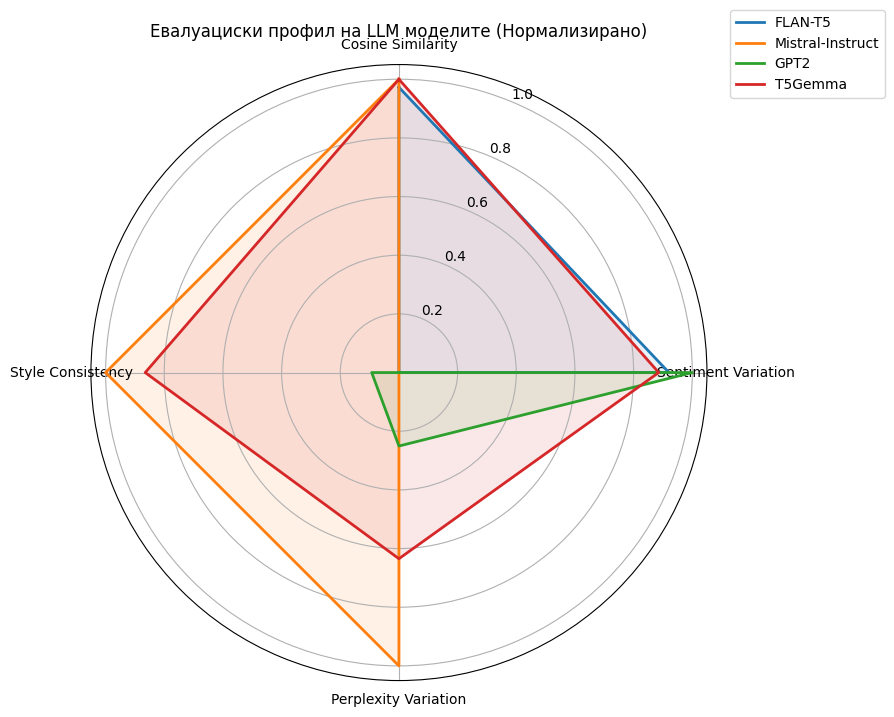

In [24]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in df_norm.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["Model"], linewidth=2)
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Евалуациски профил на LLM моделите (Нормализирано)", pad=20)
plt.show()

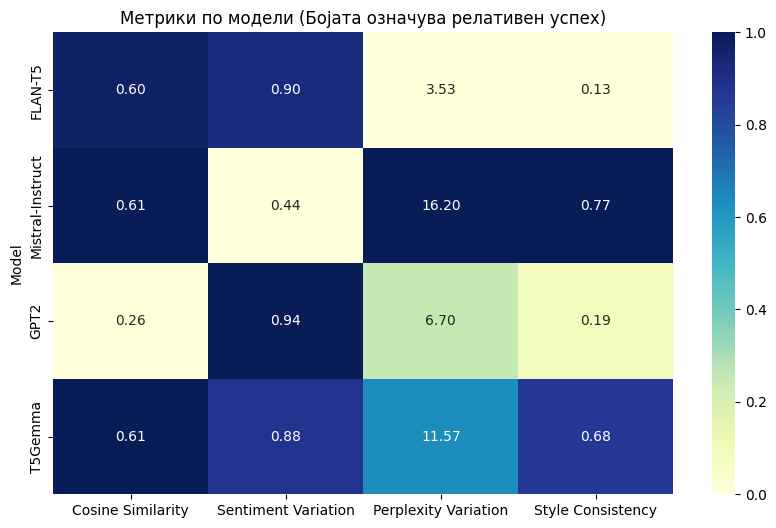

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_norm.set_index("Model"), annot=metrics_table.set_index("Model"),
            fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Метрики по модели (Бојата означува релативен успех)")
plt.show()

In [26]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT2", "T5Gemma"],
    "Cosine Similarity": [0.6016,
        0.6113,
        0.2610,
        0.6112],
    "Sentiment Variation": [0.8956,
        0.4352,
        0.9354,
        0.8782],
    "Perplexity Variation": [3.5276,
        16.2034,
        6.7028,
        11.5722],
    "Style Consistency": [0.1333,
        0.7653,
        0.1920,
        0.6800]
})

In [27]:
metrics = ["Cosine Similarity", "Sentiment Variation", "Perplexity Variation", "Style Consistency"]
models = metrics_table["Model"]

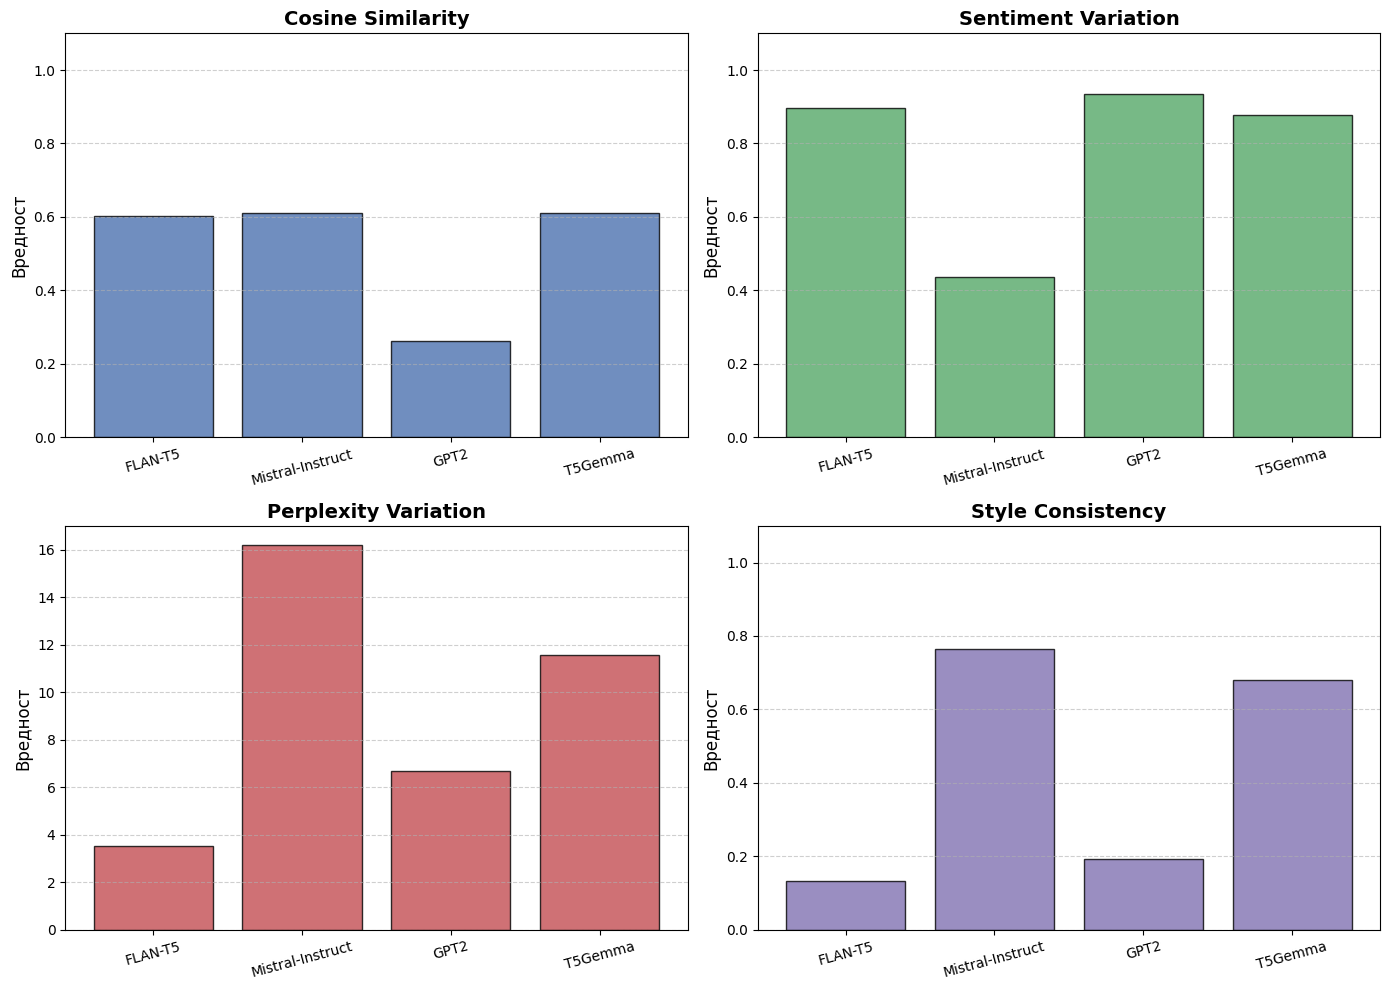

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, metric in enumerate(metrics):
    axes[i].bar(models, metrics_table[metric], color=colors[i], edgecolor='black', alpha=0.8)

    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Вредност', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    if metric != "Perplexity Variation":
        axes[i].set_ylim(0, 1.1)

    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()